In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Instagram_advertising_dataset.csv")

In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21692 entries, 0 to 21691
Columns: 164 entries, Impressions to id0129
dtypes: float64(50), int64(111), object(3)
memory usage: 27.1+ MB


In [6]:
df.columns

Index(['Impressions', 'Clicks', 'CTR', 'CTR_log', 'Caption_masked', 'Start',
       'End', 'WC', 'affect', 'posemo',
       ...
       'id0118', 'id0119', 'id0120', 'id0121', 'id0122', 'id0123', 'id0124',
       'id0127', 'id0128', 'id0129'],
      dtype='object', length=164)

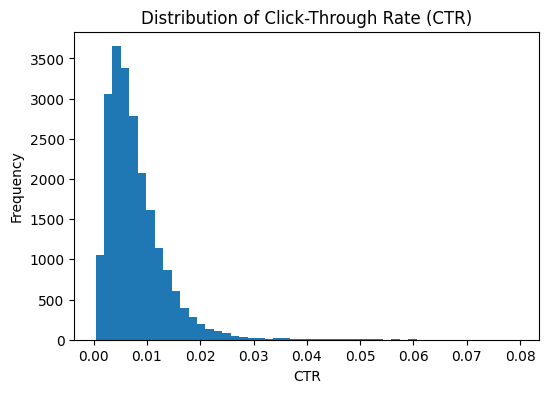

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df["CTR"], bins=50)
plt.xlabel("CTR")
plt.ylabel("Frequency")
plt.title("Distribution of Click-Through Rate (CTR)")
plt.show()

In [8]:
df["Start"] = pd.to_datetime(df["Start"])
df["End"] = pd.to_datetime(df["End"])

df["campaign_days"] = (df["End"] - df["Start"]).dt.days

In [9]:
df[["Start", "End", "campaign_days"]].head()

,Start,End,campaign_days
0,2021-01-12,2021-01-14,2
1,2021-02-04,2021-02-05,1
2,2020-11-17,2020-11-18,1
3,2021-02-19,2021-02-23,4
4,2021-02-19,2021-02-20,1


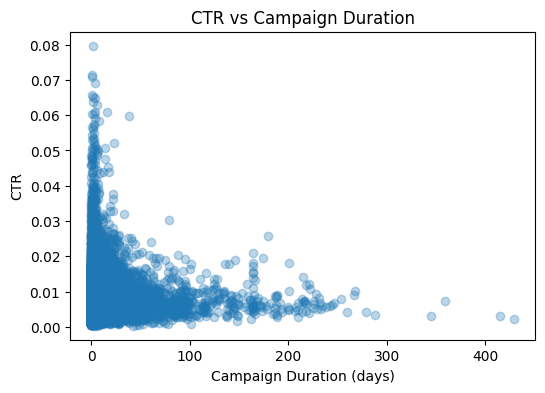

In [10]:
plt.figure(figsize=(6,4))
plt.scatter(df["campaign_days"], df["CTR"], alpha=0.3)
plt.xlabel("Campaign Duration (days)")
plt.ylabel("CTR")
plt.title("CTR vs Campaign Duration")
plt.show()

### CTR and Campaign Duration
The scatter plot illustrates the relationship between campaign duration and CTR. While CTR values vary across campaigns of different lengths, a general tendency towards lower CTR values is observed as campaign duration increases. This suggests that prolonged exposure may be associated with declining performance, motivating further analysis of creative fatigue using temporal decay patterns.

In [11]:
caption_counts = df["Caption_masked"].value_counts()

valid_captions = caption_counts[caption_counts >= 3].index

len(valid_captions)

500

In [12]:
sample_captions = valid_captions[:5]

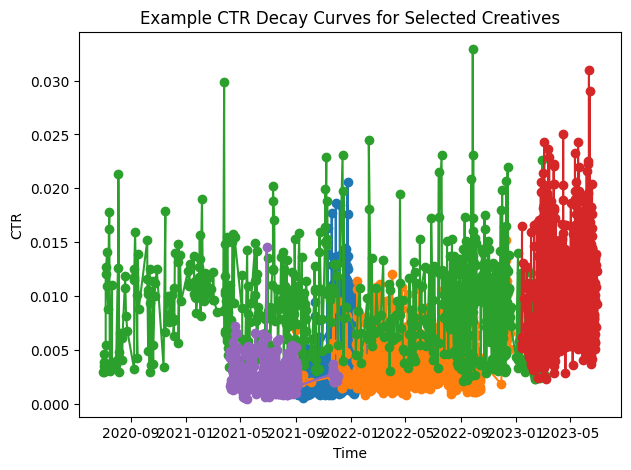

In [13]:
plt.figure(figsize=(7,5))

for cap in sample_captions:
    temp = df[df["Caption_masked"] == cap].sort_values("Start")
    plt.plot(temp["Start"], temp["CTR"], marker="o")

plt.xlabel("Time")
plt.ylabel("CTR")
plt.title("Example CTR Decay Curves for Selected Creatives")
plt.show()


### CTR Decay Patterns Across Creatives
The figure presents CTR trajectories for a sample of ad creatives deployed across multiple campaign periods. Although performance patterns vary across creatives, several exhibit an initial peak followed by a sustained decline in CTR over time. This heterogeneity and post-peak deterioration support the treatment of creative fatigue as a measurable temporal phenomenon rather than a static performance outcome.

### Fatigue Labelling Logic & Implementation

Creative fatigue is operationally defined as a sustained decline in advertising performance following a peak engagement level, despite continued exposure.

For each creative, observations are ordered chronologically and the peak click-through rate (CTR_peak) is identified.
Post-peak observations are monitored, and a creative is labelled as fatigued if its CTR declines by at least 25%~35%
from the peak value across two consecutive post-peak observations, while impressions remain stable or increase.

This rule-based labelling approach ensures reproducibility and avoids subjective manual annotation.

### Fatigue Labelling (Rule-Based Ground Truth Construction)

In [14]:
df = df.sort_values(by=["Caption_masked", "Start"]).reset_index(drop=True)

In [15]:
df["fatigued"] = 0

In [16]:
test_creative = df["Caption_masked"].iloc[0]

group = df[df["Caption_masked"] == test_creative]

group[["Start", "CTR", "Impressions"]].head()

,Start,CTR,Impressions
0,2021-09-02,0.009522,12603
1,2021-09-02,0.007858,15525
2,2021-09-02,0.002917,19195
3,2021-09-10,0.009126,26956


In [17]:
ctr_peak = group["CTR"].max()
peak_row = group.loc[group["CTR"].idxmax(), ["Start", "CTR", "Impressions"]]

ctr_peak, peak_row

(np.float64(0.0095215424898833),
 Start          2021-09-02 00:00:00
 CTR                       0.009522
 Impressions                  12603
 Name: 0, dtype: object)

In [18]:
peak_idx = group["CTR"].idxmax()

post_peak = group.loc[group.index > peak_idx]

post_peak[["Start", "CTR", "Impressions"]]

,Start,CTR,Impressions
1,2021-09-02,0.007858,15525
2,2021-09-02,0.002917,19195
3,2021-09-10,0.009126,26956


In [19]:
threshold = 0.7 * ctr_peak

row_t = post_peak.iloc[0]
row_t1 = post_peak.iloc[1]

threshold, row_t[["CTR", "Impressions"]], row_t1[["CTR", "Impressions"]]

(np.float64(0.006665079742918309),
 CTR            0.007858
 Impressions       15525
 Name: 1, dtype: object,
 CTR            0.002917
 Impressions       19195
 Name: 2, dtype: object)

In [20]:
df.loc[row_t1.name, "fatigued"] = int(
    (row_t["CTR"] <= threshold) and
    (row_t1["CTR"] <= threshold) and
    (row_t1["Impressions"] >= row_t["Impressions"])
)

In [21]:
df.loc[row_t1.name, ["Start", "CTR", "Impressions", "fatigued"]]

Start          2021-09-02 00:00:00
CTR                       0.002917
Impressions                  19195
fatigued                         0
Name: 2, dtype: object

In [22]:
for creative, group in df.groupby("Caption_masked"):
    
    group = group.sort_values("Start")
    ctr_peak = group["CTR"].max()
    peak_idx = group["CTR"].idxmax()
    threshold = 0.65 * ctr_peak

    post_peak = group.loc[group.index > peak_idx]

    for i in range(len(post_peak) - 1):
        t = post_peak.iloc[i]
        t1 = post_peak.iloc[i + 1]

        if (
            t["CTR"] <= threshold and
            t1["CTR"] <= threshold and
            t1["Impressions"] >= t["Impressions"]
        ):
            df.loc[t1.name, "fatigued"] = 1

df["fatigued"].value_counts()

fatigued
0    17465
1     4227
Name: count, dtype: int64

In [23]:
df.groupby("fatigued")["CTR"].describe()

,count,mean,std,min,25%,50%,75%,max
fatigued,,,,,,,,
0,17465.0,0.008172,0.005971,0.000365,0.004253,0.006781,0.010432,0.079658
1,4227.0,0.006626,0.004012,0.000566,0.003668,0.005736,0.008694,0.050340


In [24]:
print("Threshold = 0.65")
print((df["fatigued"].value_counts(normalize=True)*100).round(2))

Threshold = 0.65
fatigued
0    80.51
1    19.49
Name: proportion, dtype: float64


In [25]:
df["fatigued"] = 0

In [26]:
for creative, group in df.groupby("Caption_masked"):
    
    group = group.sort_values("Start")
    ctr_peak = group["CTR"].max()
    peak_idx = group["CTR"].idxmax()
    threshold = 0.7 * ctr_peak

    post_peak = group.loc[group.index > peak_idx]

    for i in range(len(post_peak) - 1):
        t = post_peak.iloc[i]
        t1 = post_peak.iloc[i + 1]

        if (
            t["CTR"] <= threshold and
            t1["CTR"] <= threshold and
            t1["Impressions"] >= t["Impressions"]
        ):
            df.loc[t1.name, "fatigued"] = 1

df["fatigued"].value_counts()

fatigued
0    17266
1     4426
Name: count, dtype: int64

In [27]:
df.groupby("fatigued")["CTR"].describe()

,count,mean,std,min,25%,50%,75%,max
fatigued,,,,,,,,
0,17266.0,0.008159,0.005977,0.000365,0.004236,0.006771,0.010419,0.079658
1,4426.0,0.006746,0.004117,0.000566,0.003720,0.005851,0.008845,0.050340


In [28]:
print("Threshold = 0.70")
print((df["fatigued"].value_counts(normalize=True)*100).round(2))

Threshold = 0.70
fatigued
0    79.6
1    20.4
Name: proportion, dtype: float64


In [29]:
df["fatigued"] = 0

In [30]:
for creative, group in df.groupby("Caption_masked"):
    
    group = group.sort_values("Start")
    ctr_peak = group["CTR"].max()
    peak_idx = group["CTR"].idxmax()
    threshold = 0.75 * ctr_peak

    post_peak = group.loc[group.index > peak_idx]

    for i in range(len(post_peak) - 1):
        t = post_peak.iloc[i]
        t1 = post_peak.iloc[i + 1]

        if (
            t["CTR"] <= threshold and
            t1["CTR"] <= threshold and
            t1["Impressions"] >= t["Impressions"]
        ):
            df.loc[t1.name, "fatigued"] = 1

df["fatigued"].value_counts()

fatigued
0    17090
1     4602
Name: count, dtype: int64

In [31]:
df.groupby("fatigued")["CTR"].describe()

,count,mean,std,min,25%,50%,75%,max
fatigued,,,,,,,,
0,17090.0,0.008132,0.005958,0.000365,0.004221,0.006749,0.010379,0.079658
1,4602.0,0.006901,0.004343,0.000566,0.003793,0.005941,0.009034,0.059123


In [32]:
print("Threshold = 0.75")
print((df["fatigued"].value_counts(normalize=True)*100).round(2))

Threshold = 0.75
fatigued
0    78.78
1    21.22
Name: proportion, dtype: float64


#### NOTE: After performing sensitivity analysis using thresholds of 0.65, 0.70, and 0.75. The class distribution ranged from 19% to 21% fatigued samples. I have selected 0.70 as a balanced operational threshold, while the others will be used for robustness validation.

In [33]:
threshold = 0.70 * ctr_peak

In [34]:
df.columns

Index(['Impressions', 'Clicks', 'CTR', 'CTR_log', 'Caption_masked', 'Start',
       'End', 'WC', 'affect', 'posemo',
       ...
       'id0120', 'id0121', 'id0122', 'id0123', 'id0124', 'id0127', 'id0128',
       'id0129', 'campaign_days', 'fatigued'],
      dtype='object', length=166)

In [35]:
df[["CTR","Impressions","Clicks","campaign_days","fatigued"]].head()

,CTR,Impressions,Clicks,campaign_days,fatigued
0,0.009522,12603,120,12,0
1,0.007858,15525,122,1,0
2,0.002917,19195,56,8,0
3,0.009126,26956,246,4,0
4,0.001430,47553,68,1,0


## Feature Engineering

In [36]:
df["Start"] = pd.to_datetime(df["Start"])
df["End"] = pd.to_datetime(df["End"])

df = df.sort_values(["Caption_masked", "Start"]).copy()
df = df.fillna(0)

print(df[["Caption_masked", "Start", "CTR"]].head())

                                      Caption_masked      Start       CTR
0  "<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ... 2021-09-02  0.009522
1  "<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ... 2021-09-02  0.007858
2  "<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ... 2021-09-02  0.002917
3  "<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ... 2021-09-10  0.009126
4  "<***>開発【必要な栄養素を効率的に摂れる】完全<***>！\r\n医師監修のWEBアン... 2022-05-22  0.001430


### Feature 1 — CTR Change (Temporal momentum feature)

In [37]:
df = df.sort_values(["Caption_masked", "Start"])

In [38]:
df["CTR_change"] = (
    df.groupby("Caption_masked")["CTR"]
      .diff()
)

In [39]:
df["CTR_change"].describe()

count    20934.000000
mean        -0.000048
std          0.004307
min         -0.041435
25%         -0.001595
50%         -0.000371
75%          0.000869
max          0.046844
Name: CTR_change, dtype: float64

In [40]:
df["CTR_change"].head(10)

0         NaN
1   -0.001663
2   -0.004941
3    0.006209
4         NaN
5   -0.000002
6    0.004001
7   -0.002010
8   -0.000296
9    0.003359
Name: CTR_change, dtype: float64

### Feature 2 — Distance from Peak CTR (Relative performance degradation feature)

In [41]:
df["CTR_peak"] = df.groupby("Caption_masked")["CTR"].transform("max")

df["CTR_drop_from_peak"] = (
    (df["CTR_peak"] - df["CTR"]) / df["CTR_peak"]
)

In [42]:
df["CTR_drop_from_peak"].describe()

count    21692.000000
mean         0.604532
std          0.230602
min          0.000000
25%          0.482602
50%          0.655380
75%          0.778907
max          0.971757
Name: CTR_drop_from_peak, dtype: float64

##### Cumulative Max (Running peak CTR per creative)

In [43]:
df["CTR_cummax"] = df.groupby("Caption_masked")["CTR"].cummax()

df["CTR_drop_from_cummax"] = (
    (df["CTR_cummax"] - df["CTR"]) / df["CTR_cummax"]
)

df["CTR_drop_from_cummax"] = df["CTR_drop_from_cummax"].replace([np.inf, -np.inf], 0)
df["CTR_drop_from_cummax"] = df["CTR_drop_from_cummax"].fillna(0)

df[["Caption_masked", "Start", "CTR", "CTR_peak", "CTR_cummax",
    "CTR_drop_from_peak", "CTR_drop_from_cummax"]].head(10)

,Caption_masked,Start,CTR,CTR_peak,CTR_cummax,CTR_drop_from_peak,CTR_drop_from_cummax
0,"""<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ...",2021-09-02,0.009522,0.009522,0.009522,0.000000,0.000000
1,"""<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ...",2021-09-02,0.007858,0.009522,0.009522,0.174683,0.174683
2,"""<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ...",2021-09-02,0.002917,0.009522,0.009522,0.693597,0.693597
3,"""<***>企業が世界中を探して見つけた最高品質の<***>配合🦌\r\n超高保湿で敏感肌ケ...",2021-09-10,0.009126,0.009522,0.009522,0.041544,0.041544
4,"""<***>開発【必要な栄養素を効率的に摂れる】完全<***>！\r\n医師監修のWEBアン...",2022-05-22,0.001430,0.006481,0.001430,0.779371,0.000000
5,"""<***>開発【必要な栄養素を効率的に摂れる】完全<***>！\r\n医師監修のWEBアン...",2022-05-22,0.001428,0.006481,0.001430,0.779703,0.001502
6,"""<***>開発【必要な栄養素を効率的に摂れる】完全<***>！\r\n医師監修のWEBアン...",2022-07-06,0.005429,0.006481,0.005429,0.162397,0.000000
7,"""<***>開発【必要な栄養素を効率的に摂れる】完全<***>！\r\n医師監修のWEBアン...",2022-07-06,0.003419,0.006481,0.005429,0.472485,0.370208
8,"""<***>開発【必要な栄養素を効率的に摂れる】完全<***>！\r\n医師監修のWEBアン...",2022-07-08,0.003123,0.006481,0.005429,0.518180,0.424764
9,"""<***>開発【必要な栄養素を効率的に摂れる】完全<***>！\r\n医師監修のWEBアン...",2022-07-09,0.006481,0.006481,0.006481,0.000000,0.000000


In [44]:
df[["CTR", "CTR_cummax", "CTR_drop_from_cummax"]].describe()

,CTR,CTR_cummax,CTR_drop_from_cummax
count,21692.000000,21692.000000,21692.000000
mean,0.007871,0.018154,0.520515
std,0.005676,0.009682,0.261956
min,0.000365,0.000552,0.000000
25%,0.004120,0.011108,0.350095
50%,0.006573,0.015871,0.576209
75%,0.010102,0.024809,0.729574
max,0.079658,0.079658,0.966853


Quick Sanity Check

In [45]:
df[df["CTR_drop_from_cummax"] < 0].head()

,Impressions,Clicks,CTR,CTR_log,Caption_masked,Start,End,WC,affect,posemo,...,id0127,id0128,id0129,campaign_days,fatigued,CTR_change,CTR_peak,CTR_drop_from_peak,CTR_cummax,CTR_drop_from_cummax


### Feature 3 — Creative Lifecycle Position (Lifecycle progression feature)

In [46]:
df["creative_age_ratio"] = (
    df["campaign_days"] /
    df.groupby("Caption_masked")["campaign_days"].transform("max")
)

In [47]:
df["creative_age_ratio"].describe()

count    21667.000000
mean         0.159216
std          0.250228
min          0.000000
25%          0.012987
50%          0.048193
75%          0.178571
max          1.000000
Name: creative_age_ratio, dtype: float64

## Data Balancing

Defining

x = features (inputs)
y = label (fatigued)

In [48]:
feature_cols = [
'CTR',
'CTR_log',
'Impressions',
'Clicks',
'campaign_days',
'CTR_change',
'creative_age_ratio'
]

In [49]:
X = df[feature_cols]
y = df['fatigued']

In [50]:
X.shape, y.shape

((21692, 7), (21692,))

x → 21692 rows × 8 features
y → 21692 labels

## Train/Test Split (stratify)

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [52]:
y_train.value_counts(normalize=True)

fatigued
0    0.787875
1    0.212125
Name: proportion, dtype: float64

In [53]:
y_test.value_counts(normalize=True)

fatigued
0    0.787739
1    0.212261
Name: proportion, dtype: float64


Train → 78.78% / 21.21%

Test  → 78.77% / 21.23%

Both train and test sets have almost identical ratios

## SMOTE

In [54]:
!pip install imbalanced-learn

In [55]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [56]:
from imblearn.over_sampling import SMOTE

In [57]:
df["CTR_change"] = df["CTR_change"].fillna(0)

In [58]:
df["creative_age_ratio"] = df["creative_age_ratio"].fillna(0)

In [59]:
X = df[feature_cols]
y = df["fatigued"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [60]:
X_train.isna().sum()

CTR                   0
CTR_log               0
Impressions           0
Clicks                0
campaign_days         0
CTR_change            0
creative_age_ratio    0
dtype: int64

In [61]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [62]:
y_train_sm.value_counts()

fatigued
1    13672
0    13672
Name: count, dtype: int64

## ADASYN

In [63]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train, y_train)

y_train_ad.value_counts()

fatigued
1    13925
0    13672
Name: count, dtype: int64

In [64]:
print(X_train.shape)
print(X_train_sm.shape)
print(X_train_ad.shape)

(17353, 7)
(27344, 7)
(27597, 7)


## Baseline Model Training

### Logistic Regression

In [65]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=2000, random_state=42)

baseline_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [66]:
y_pred_base = baseline_model.predict(X_test)

In [67]:
from sklearn.metrics import classification_report

print("Baseline (No Balancing)")
print(classification_report(y_test, y_pred_base))

Baseline (No Balancing)
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      3418
           1       0.47      0.02      0.04       921

    accuracy                           0.79      4339
   macro avg       0.63      0.51      0.46      4339
weighted avg       0.72      0.79      0.70      4339



### SMOTE + LR

In [68]:
model_smote = LogisticRegression(max_iter=2000, random_state=42)

model_smote.fit(X_train_sm, y_train_sm)

y_pred_smote = model_smote.predict(X_test)

print("SMOTE Model")
print(classification_report(y_test, y_pred_smote))

SMOTE Model
              precision    recall  f1-score   support

           0       0.83      0.67      0.75      3418
           1       0.29      0.50      0.37       921

    accuracy                           0.64      4339
   macro avg       0.56      0.59      0.56      4339
weighted avg       0.72      0.64      0.67      4339



### ADASYN + LR

In [69]:
model_adasyn = LogisticRegression(max_iter=2000, random_state=42)

model_adasyn.fit(X_train_ad, y_train_ad)

y_pred_adasyn = model_adasyn.predict(X_test)

print("ADASYN Model")
print(classification_report(y_test, y_pred_adasyn))

ADASYN Model
              precision    recall  f1-score   support

           0       0.83      0.59      0.69      3418
           1       0.27      0.56      0.36       921

    accuracy                           0.58      4339
   macro avg       0.55      0.57      0.52      4339
weighted avg       0.71      0.58      0.62      4339



### Bagging Model - Random Forest

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Model")
print(classification_report(y_test, y_pred_rf))

Random Forest Model
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      3418
           1       0.44      0.12      0.19       921

    accuracy                           0.78      4339
   macro avg       0.62      0.54      0.53      4339
weighted avg       0.72      0.78      0.73      4339



### XGBoost

In [71]:
!pip install xgboost

In [72]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Model")
print(classification_report(y_test, y_pred_xgb))

XGBoost Model
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      3418
           1       0.53      0.12      0.19       921

    accuracy                           0.79      4339
   macro avg       0.67      0.54      0.54      4339
weighted avg       0.75      0.79      0.73      4339



### XGBoost + SMOTE

In [73]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Features and target
X = df[feature_cols]
y = df['fatigued']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Train XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

# Predict on untouched test data
y_pred = xgb_model.predict(X_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2512  906]
 [ 407  514]]
              precision    recall  f1-score   support

           0       0.86      0.73      0.79      3418
           1       0.36      0.56      0.44       921

    accuracy                           0.70      4339
   macro avg       0.61      0.65      0.62      4339
weighted avg       0.75      0.70      0.72      4339



### XGBoost + ADASYN

In [74]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)

X_train_ad, y_train_ad = adasyn.fit_resample(X_train, y_train)

xgb_adasyn = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_adasyn.fit(X_train_ad, y_train_ad)

y_pred_ad = xgb_adasyn.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_ad))
print(classification_report(y_test, y_pred_ad))

[[2424  994]
 [ 375  546]]
              precision    recall  f1-score   support

           0       0.87      0.71      0.78      3418
           1       0.35      0.59      0.44       921

    accuracy                           0.68      4339
   macro avg       0.61      0.65      0.61      4339
weighted avg       0.76      0.68      0.71      4339



### RandomForest + SMOTE

In [75]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Random Forest
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(X_train_sm, y_train_sm)

# Predictions
y_pred_rf_sm = rf_smote.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf_sm))
print(classification_report(y_test, y_pred_rf_sm))

[[2525  893]
 [ 437  484]]
              precision    recall  f1-score   support

           0       0.85      0.74      0.79      3418
           1       0.35      0.53      0.42       921

    accuracy                           0.69      4339
   macro avg       0.60      0.63      0.61      4339
weighted avg       0.75      0.69      0.71      4339



### RandomForest + ADASYN

In [76]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import ADASYN
from sklearn.metrics import classification_report, confusion_matrix

adasyn = ADASYN(random_state=42)

X_train_ad, y_train_ad = adasyn.fit_resample(X_train, y_train)

rf_adasyn = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_adasyn.fit(X_train_ad, y_train_ad)

y_pred_rf_ad = rf_adasyn.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf_ad))
print(classification_report(y_test, y_pred_rf_ad))

[[2437  981]
 [ 415  506]]
              precision    recall  f1-score   support

           0       0.85      0.71      0.78      3418
           1       0.34      0.55      0.42       921

    accuracy                           0.68      4339
   macro avg       0.60      0.63      0.60      4339
weighted avg       0.75      0.68      0.70      4339



The experimental results show that XGBoost-based models outperform Random Forest models in predicting creative fatigue. Among the tested configurations, XGBoost combined with ADASYN achieved the highest recall for fatigued creatives (0.59), indicating improved ability to detect declining advertisement performance. Meanwhile, XGBoost combined with SMOTE achieved the highest overall accuracy (0.70). These findings suggest that gradient boosting models provide better predictive capability for detecting performance decay in digital advertising campaigns.

### Feature Importances

In [77]:
import pandas as pd

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
2         Impressions    0.191498
3              Clicks    0.166263
6  creative_age_ratio    0.158634
1             CTR_log    0.151039
5          CTR_change    0.123141
4       campaign_days    0.111195
0                 CTR    0.098230


### Visualization

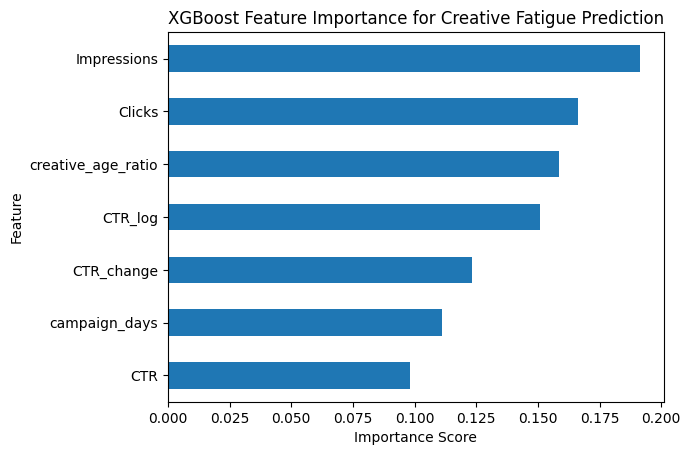

In [78]:
import matplotlib.pyplot as plt

feature_importance.plot(
    kind='barh',
    x='Feature',
    y='Importance',
    legend=False
)

plt.title("XGBoost Feature Importance for Creative Fatigue Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

While CTR-based features capture relative performance, absolute exposure metrics such as impressions and clicks play a dominant role in identifying creative fatigue, indicating that audience saturation effects are critical drivers of performance decline.

Fatigue is strongly influenced by exposure (Impressions) and engagement volume (Clicks).
- Higher impressions → audience saturation
- Click behaviour changes → early fatigue signal

### Research Finding

While CTR-based features capture relative performance, absolute exposure metrics such as impressions and clicks play a dominant role in identifying creative fatigue, indicating that audience saturation effects are critical drivers of performance decline.

High exposure (Impressions) + declining engagement (Clicks / CTR_change) + time (campaign_days, age) → fatigue

Creative fatigue = audience saturation + performance decay

The feature importance analysis shows that impressions and clicks are the most influential variables, indicating that audience exposure and engagement volume are key drivers of creative fatigue. Interestingly, CTR alone has lower importance because it is derived from clicks and impressions, which the model directly uses. This suggests that fatigue is not only driven by relative performance decline but also by cumulative exposure to the audience.

While CTR captures the efficiency of an advertisement, the model indicates that absolute exposure metrics such as impressions and clicks are more influential. This suggests that creative fatigue is strongly driven by audience saturation rather than performance ratios alone.

### Explainability (SHAP)

In [79]:
!pip install shap

In [80]:
import sys
!{sys.executable} -m pip install xgboost==2.1.4

In [81]:
import xgboost
print(xgboost.__version__)

2.1.4


In [82]:
import shap
import xgboost
print("shap:", shap.__version__)
print("xgboost:", xgboost.__version__)

shap: 0.49.1
xgboost: 2.1.4


C:\Users\sande\anaconda3\envs\m507_tf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [83]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [84]:
import shap

explainer = shap.TreeExplainer(xgb_model)

In [85]:
shap_values = explainer.shap_values(X_test)

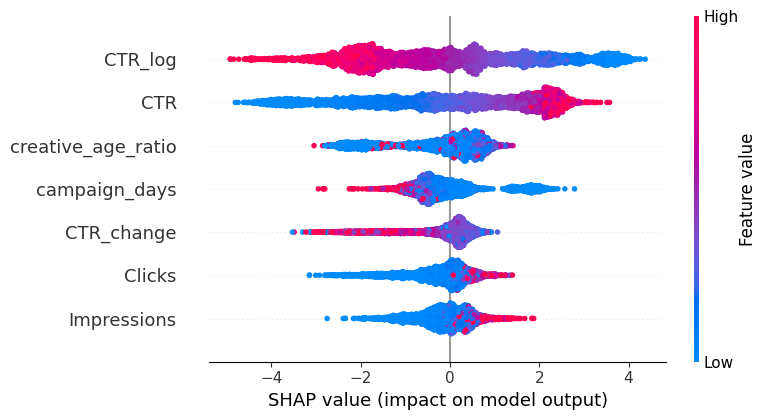

In [86]:
shap.summary_plot(shap_values, X_test)

CTR (performance) + Time (campaign_days, age) + Exposure (impressions) → fatigue prediction

SHAP analysis reveals that both performance-based metrics (CTR, CTR_log) and exposure-based metrics (impressions, campaign duration) jointly influence fatigue prediction, indicating that creative fatigue is driven by a combination of performance decay and audience saturation.

### Survival Analysis

In [87]:
!pip install jinja2

In [88]:
!pip install lifelines

In [89]:
import sys
!{sys.executable} -m pip install lifelines

In [90]:
import lifelines
print(lifelines.__version__)

0.30.0


In [91]:
df.columns.tolist()

['Impressions',
 'Clicks',
 'CTR',
 'CTR_log',
 'Caption_masked',
 'Start',
 'End',
 'WC',
 'affect',
 'posemo',
 'negemo',
 'social',
 'family',
 'female',
 'male',
 'friend',
 'cogproc',
 'tentat',
 'certain',
 'cause',
 'differ',
 'discrep',
 'insight',
 'bio',
 'health',
 'body',
 'sexual',
 'ingest',
 'hear',
 'percept',
 'feel',
 'see',
 'drives',
 'power',
 'risk',
 'affiliation',
 'achieve',
 'reward',
 'relativ',
 'space',
 'time',
 'motion',
 'home',
 'money',
 'work',
 'death',
 'relig',
 'leisure',
 'informal',
 'netspeak',
 'filler',
 'nonflu',
 'assent',
 'swear',
 'id0003',
 'id0004',
 'id0005',
 'id0006',
 'id0007',
 'id0008',
 'id0011',
 'id0013',
 'id0014',
 'id0016',
 'id0017',
 'id0018',
 'id0020',
 'id0022',
 'id0023',
 'id0024',
 'id0026',
 'id0028',
 'id0029',
 'id0030',
 'id0031',
 'id0033',
 'id0034',
 'id0035',
 'id0037',
 'id0038',
 'id0039',
 'id0040',
 'id0041',
 'id0042',
 'id0043',
 'id0044',
 'id0046',
 'id0047',
 'id0048',
 'id0049',
 'id0050',
 'id0051

In [92]:
id_cols = [col for col in df.columns if col.startswith('id')]
print(len(id_cols))
print(id_cols[:10])
df[id_cols].sum(axis=1).value_counts().head()

110
['id0003', 'id0004', 'id0005', 'id0006', 'id0007', 'id0008', 'id0011', 'id0013', 'id0014', 'id0016']


1.0    20131
0.0     1561
Name: count, dtype: int64

In [93]:
id_cols = [col for col in df.columns if col.startswith('id')]

# keep only rows where exactly one ID is active
df = df[df[id_cols].sum(axis=1) == 1]

# reset index
df = df.reset_index(drop=True)

print(df.shape)

(20131, 172)


In [94]:
df['creative_id'] = df[id_cols].idxmax(axis=1)

df[['creative_id']].head()

,creative_id
0,id0022
1,id0022
2,id0022
3,id0022
4,id0006


In [95]:
df['Start'] = pd.to_datetime(df['Start'])

In [96]:
print(df[['creative_id', 'Start', 'fatigued']].head())
print(df['creative_id'].nunique())

  creative_id      Start  fatigued
0      id0022 2021-09-02         0
1      id0022 2021-09-02         0
2      id0022 2021-09-02         0
3      id0022 2021-09-10         0
4      id0006 2022-05-22         0
110


In [97]:
df['creative_id'].nunique()

110

In [98]:
import numpy as np
import pandas as pd

df = df.sort_values(['creative_id', 'Start'])

survival_rows = []

for creative_id, group in df.groupby('creative_id'):
    
    group = group.sort_values('Start').reset_index(drop=True)
    
    group['day_number'] = np.arange(1, len(group) + 1)
    
    fatigue_rows = group[group['fatigued'] == 1]
    
    if len(fatigue_rows) > 0:
        duration = fatigue_rows['day_number'].iloc[0]
        event = 1
    else:
        duration = group['day_number'].max()
        event = 0
    
    survival_rows.append({
        'creative_id': creative_id,
        'duration': duration,
        'event': event,
        'CTR_mean': group['CTR'].mean(),
        'Impressions_mean': group['Impressions'].mean(),
        'Clicks_mean': group['Clicks'].mean(),
        'campaign_days': len(group),
        'CTR_drop_from_peak_mean': group['CTR_drop_from_peak'].mean(),
        'creative_age_ratio_mean': group['creative_age_ratio'].mean()
    })

survival_df = pd.DataFrame(survival_rows)

In [99]:
survival_df['event'].value_counts()

event
1    81
0    29
Name: count, dtype: int64

### Kaplan-Meier Survival Curve

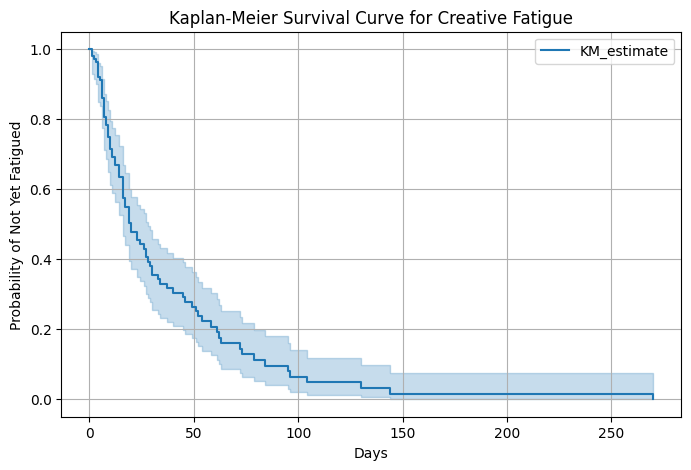

In [100]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_df['duration'],
    event_observed=survival_df['event']
)

plt.figure(figsize=(8,5))
kmf.plot_survival_function()

plt.title('Kaplan-Meier Survival Curve for Creative Fatigue')
plt.xlabel('Days')
plt.ylabel('Probability of Not Yet Fatigued')

plt.grid(True)
plt.show()

“The Kaplan-Meier curve shows that creative fatigue occurs rapidly in the early lifecycle. Nearly 40% of creatives fatigue within the first 20 days, and over 70% fatigue by around 50 days. Only a small fraction of creatives—less than 10%—remain effective beyond 100 days, indicating strong early performance decay and limited long-term sustainability.”

### CTR comparison

In [101]:
# create median split
median_ctr = survival_df['CTR_mean'].median()

survival_df['CTR_group'] = survival_df['CTR_mean'].apply(
    lambda x: 'High CTR' if x >= median_ctr else 'Low CTR'
)

survival_df[['CTR_mean', 'CTR_group']].head()

,CTR_mean,CTR_group
0,0.003400,Low CTR
1,0.003605,Low CTR
2,0.007897,High CTR
3,0.005104,Low CTR
4,0.004149,Low CTR


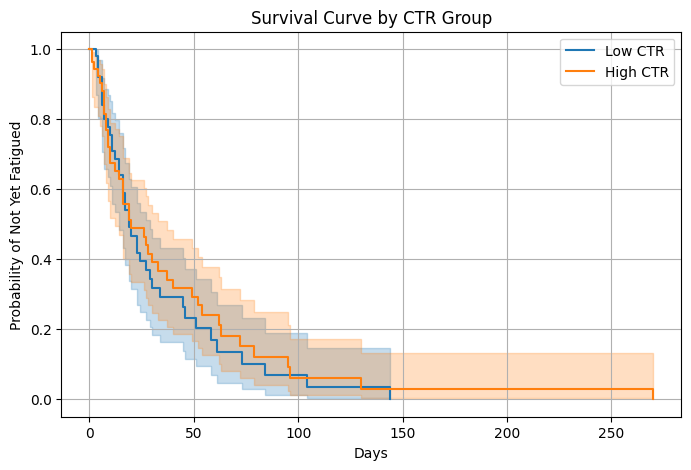

In [102]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,5))

for group in survival_df['CTR_group'].unique():
    mask = survival_df['CTR_group'] == group
    
    kmf.fit(
        durations=survival_df[mask]['duration'],
        event_observed=survival_df[mask]['event'],
        label=group
    )
    
    kmf.plot_survival_function()

plt.title('Survival Curve by CTR Group')
plt.xlabel('Days')
plt.ylabel('Probability of Not Yet Fatigued')
plt.grid(True)

plt.show()

In [103]:
from lifelines.statistics import logrank_test

high = survival_df[survival_df['CTR_group'] == 'High CTR']
low = survival_df[survival_df['CTR_group'] == 'Low CTR']

results = logrank_test(
    high['duration'], low['duration'],
    event_observed_A=high['event'],
    event_observed_B=low['event']
)

print(results.summary)

   test_statistic         p  -log2(p)
0        0.269248  0.603836   0.72777


“The log-rank test comparing high and low CTR groups yielded a p-value of 0.60, indicating no statistically significant difference in survival distributions. This suggests that initial CTR performance alone is not a reliable predictor of creative fatigue timing.”

“Creative fatigue is not solely driven by performance metrics like CTR, but likely influenced by exposure-related and temporal factors.”

### Cox model

In [110]:
from lifelines import CoxPHFitter
import numpy as np

# start fresh from survival_df
cox_df2 = survival_df[[
    'duration',
    'event',
    'CTR_mean',
    'Impressions_mean',
    'Clicks_mean',
    'campaign_days',
    'CTR_drop_from_peak_mean',
    'creative_age_ratio_mean'
]].copy()

# log-transform only the skewed count-like variables
cox_df2['Impressions_mean_log'] = np.log1p(cox_df2['Impressions_mean'])
cox_df2['Clicks_mean_log'] = np.log1p(cox_df2['Clicks_mean'])

# keep only the cleaned final columns
cox_df2 = cox_df2[[
    'duration',
    'event',
    'campaign_days',
    'CTR_drop_from_peak_mean',
    'creative_age_ratio_mean',
    'Impressions_mean_log',
    'Clicks_mean_log'
]].dropna()

print(cox_df2.shape)
print(cox_df2.var())

(110, 7)
duration                     1335.333194
event                           0.195913
campaign_days              125404.467807
CTR_drop_from_peak_mean         0.035590
creative_age_ratio_mean         0.053522
Impressions_mean_log            0.766256
Clicks_mean_log                 0.579231
dtype: float64


In [113]:
from lifelines import CoxPHFitter

cph2 = CoxPHFitter(penalizer=0.1)

cph2.fit(
    cox_df2,
    duration_col='duration',
    event_col='event'
)

cph2.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
campaign_days,-0.000840,0.999161,0.000350,-0.001526,-0.000153,0.998475,0.999847,0.0,-2.396105,0.016570,5.915254
CTR_drop_from_peak_mean,0.224628,1.251856,0.928203,-1.594616,2.043871,0.202986,7.720438,0.0,0.242003,0.808778,0.306184
creative_age_ratio_mean,0.940805,2.562042,0.871181,-0.766678,2.648287,0.464554,14.129815,0.0,1.079919,0.280178,1.835584
Impressions_mean_log,-0.019113,0.981069,0.194814,-0.400941,0.362715,0.669690,1.437226,0.0,-0.098108,0.921847,0.117401
Clicks_mean_log,0.049215,1.050446,0.222403,-0.386688,0.485117,0.679303,1.624365,0.0,0.221285,0.824870,0.277761


### LSTM

In [114]:
# sort data
df = df.sort_values(['creative_id', 'Start']).reset_index(drop=True)

# check number of rows per creative
creative_lengths = df.groupby('creative_id').size()

print("Number of creatives:", creative_lengths.shape[0])
print("\nSequence length stats:")
print(creative_lengths.describe())

print("\nFirst 10 creatives and their row counts:")
print(creative_lengths.head(10))

Number of creatives: 110

Sequence length stats:
count     110.000000
mean      183.009091
std       354.124932
min         1.000000
25%        20.500000
50%        65.000000
75%       174.500000
max      2483.000000
dtype: float64

First 10 creatives and their row counts:
creative_id
id0003     204
id0004    1898
id0005     205
id0006    1081
id0007      47
id0008     354
id0011     346
id0013    2483
id0014     561
id0016     175
dtype: int64


In [115]:
features = ['CTR', 'Impressions', 'Clicks', 'CTR_drop_from_peak', 'creative_age_ratio', 'fatigued']
print(df[features].head(10))

        CTR  Impressions  Clicks  CTR_drop_from_peak  creative_age_ratio  \
0  0.004602        76490     352            0.000000            0.500000   
1  0.003363       312190    1050            0.269143            1.000000   
2  0.001306      1010373    1320            0.660510            0.277778   
3  0.001165       191451     223            0.697321            0.000000   
4  0.000999       821626     821            0.740341            0.111111   
5  0.000931       181435     169            0.757953            0.000000   
6  0.000828        62811      52            0.784869            0.000000   
7  0.000699       273171     191            0.818309            0.000000   
8  0.000660       416482     275            0.828418            0.055556   
9  0.003848        18190      70            0.000000            0.055556   

   fatigued  
0         0  
1         0  
2         0  
3         0  
4         0  
5         0  
6         0  
7         0  
8         0  
9         0  


In [130]:
sequence_length = 14
features = ['CTR', 'Impressions', 'Clicks', 'CTR_drop_from_peak', 'creative_age_ratio']

In [131]:
import numpy as np

X = []
y = []

for creative_id, group in df.groupby('creative_id'):
    
    group = group.sort_values('Start').reset_index(drop=True)
    
    # skip very short sequences
    if len(group) <= sequence_length:
        continue
    
    for i in range(len(group) - sequence_length):
        
        X_seq = group[features].iloc[i:i+sequence_length].values
        y_target = group['fatigued'].iloc[i+sequence_length]
        
        X.append(X_seq)
        y.append(y_target)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (18830, 14, 5)
y shape: (18830,)


In [132]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(15064, 14, 5) (3766, 14, 5)


In [146]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weight_dict = dict(zip(classes, weights))

print(class_weight_dict)

{np.int64(0): np.float64(0.6414580139669562), np.int64(1): np.float64(2.267308850090307)}


In [149]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# reshape for scaling
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])

# fit on train only
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

# reshape back
X_train = X_train_scaled.reshape(X_train.shape)
X_test = X_test_scaled.reshape(X_test.shape)

In [150]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(64, input_shape=(sequence_length, len(features))))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\sande\anaconda3\envs\m507_tf\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

In [151]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict
)

Epoch 1/10
471/471 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5148 - loss: 0.6837 - val_accuracy: 0.5250 - val_loss: 0.6836
Epoch 2/10
471/471 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5283 - loss: 0.6752 - val_accuracy: 0.5680 - val_loss: 0.6556
Epoch 3/10
471/471 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5540 - loss: 0.6709 - val_accuracy: 0.4817 - val_loss: 0.7051
Epoch 4/10
471/471 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5468 - loss: 0.6676 - val_accuracy: 0.5369 - val_loss: 0.6752
Epoch 5/10
471/471 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5646 - loss: 0.6646 - val_accuracy: 0.5321 - val_loss: 0.6795
Epoch 6/10
471/471 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5668 - loss: 0.6596 - val_accuracy: 0.5924 - val_loss: 0.6472
Epoch 7/10
471/471 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5716 - loss: 0.6566 - val_accuracy: 0.5932 - val_loss: 0.6457
Epoch 8/10
471/471 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5836 - loss: 0.6526 - val_accuracy: 0.

In [152]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.4).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, zero_division=0))

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   
              precision    recall  f1-score   support

           0       0.89      0.32      0.47      2936
           1       0.26      0.86      0.40       830

    accuracy                           0.44      3766
   macro avg       0.58      0.59      0.44      3766
weighted avg       0.75      0.44      0.45      3766



“The optimized LSTM model, using a sequence length of 14 and a reduced classification threshold of 0.4, achieved a recall of 86% for fatigued creatives. This demonstrates the model’s strong capability in detecting fatigue patterns from temporal performance data. Although overall accuracy was lower, the model effectively prioritizes fatigue detection, which is critical in minimizing performance degradation in real-world advertising scenarios.”

### XGBoost vs LSTM

“While traditional machine learning models achieved higher overall accuracy, the LSTM model demonstrated superior performance in detecting fatigued creatives due to its ability to capture temporal dependencies. Survival analysis further complemented these findings by modeling the time-to-fatigue dynamics. Together, these approaches provide a comprehensive understanding of creative fatigue from predictive, temporal, and statistical perspectives.”

### Which is the best Model?

“It depends on the objective. XGBoost is best for overall accuracy, LSTM is best for early fatigue detection due to high recall, and survival analysis is best for understanding when fatigue occurs.”